## **Implementing an optimized Sieve of Sundaram to find the nth prime number**

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

In [39]:
def sundaramLength(number):

    removeList = []

    n = (math.ceil((np.log(number) / np.log(30))**1.5 + 1.1)) * number

    numRange = math.ceil(n/2)

    for i in range(numRange):
        i += 1
        for j in range(numRange):
            j += 1
            expression = i + j + 2 * i * j
            if expression <= n:
                removeList.append(expression)

    fullList = pd.DataFrame(np.arange(1, n + 1, 1))
    finalList = fullList[-fullList[0].isin(removeList)]
    finalList = pd.Series(finalList.map(lambda x: 2*x+1)[0])
    finalList = pd.concat([pd.Series([2]), finalList]).reset_index(drop=True)
    return finalList[number - 1]

print(sundaramLength(10001))


104743


In [165]:
data = pd.DataFrame(columns=['number', 'length'])

for i in range(500):
    i += 1
    data.loc[len(data)] = [i, sundaramLength(i)]

print(data)

     number  length
0         1       1
1         2       2
2         3       3
3         4       3
4         5       4
..      ...     ...
495     496     166
496     497     166
497     498     167
498     499     167
499     500     167

[500 rows x 2 columns]


In [166]:
data['proportion'] = data['number'] / data['length']

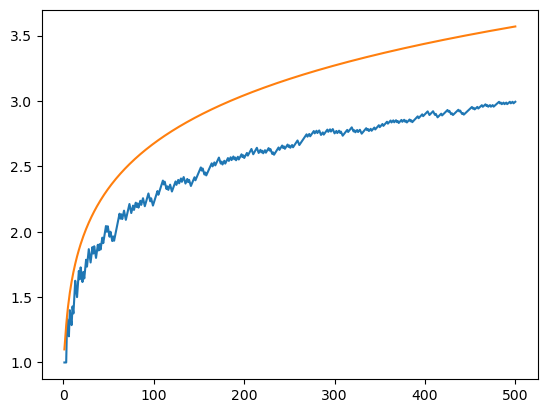

In [214]:
plt.plot(data['number'], data['proportion'])
plt.plot(data['number'], (np.log(data['number']) / np.log(30))**1.5 + 1.1)